<a href="https://colab.research.google.com/github/Mogatala8374/Vehicle-dataset---Complete-Dataset/blob/main/Vehicle_Dataset_(CarDekho).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -



##### **Project Type**    - Regression
##### **Contribution**    - Individual
##### **Team Member 1 -** Mogatala Yuvaraju
##### **Team Member 2 -**
##### **Team Member 3 -**
##### **Team Member 4 -**

# **Project Summary -**

Write the summary here within 500-600 words.

# Project Summary

**Title: Car Price Prediction using Linear Regression, Ridge Regression, and Lasso Regression**

The objective of this project is to develop a machine learning model capable of predicting the selling price of used cars using regression techniques. The project uses the **Car Details v3** dataset, which contains information about used vehicles, including features such as car name, manufacturing year, kilometers driven, fuel type, seller type, transmission, owner type, mileage, engine capacity, maximum power, seating capacity, and selling price. Since the dataset contains both missing values and categorical variables, it provides an excellent opportunity to perform comprehensive data preprocessing and feature engineering before building predictive models.

The project begins with **Exploratory Data Analysis (EDA)** to understand the dataset's structure and characteristics. Basic operations such as viewing the dataset, checking its dimensions, identifying data types, generating descriptive statistics, and detecting duplicate records were performed. Missing values were identified using summary statistics and heatmaps, allowing a clear understanding of data quality. Visualizations including histograms, boxplots, count plots, pair plots, and correlation heatmaps were used to examine the distribution of variables, detect outliers, and understand relationships between features and the target variable.

A major part of the project focuses on **Feature Engineering and Data Pre-processing**. Missing numerical values were replaced using the median, while missing categorical values were filled using the mode to preserve the integrity of the data. Duplicate records were removed to avoid redundant information during model training. A new feature called **Car Age** was created by subtracting the manufacturing year from the current year, providing a more meaningful representation of a vehicle's age. The original year column was then removed to eliminate redundancy. Outliers in numerical features were detected and removed using the Interquartile Range (IQR) method, improving model robustness. Categorical variables were converted into numerical form using Label Encoding, and all numerical features were standardized using StandardScaler to ensure consistent feature scaling. Finally, the dataset was divided into training and testing sets using an 80:20 split for model evaluation.

Three regression algorithms were implemented and compared in this project: **Linear Regression, Ridge Regression, and Lasso Regression**. Linear Regression served as the baseline model for predicting car prices. Ridge Regression introduced L2 regularization to reduce overfitting by penalizing large coefficients, while Lasso Regression applied L1 regularization, which also performs feature selection by shrinking less important coefficients toward zero. Hyperparameter tuning was performed for Ridge and Lasso regression using different alpha values to identify the most suitable level of regularization.

The performance of each model was evaluated using several regression metrics, including **Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and the R² Score**. Lower MAE, MSE, and RMSE values indicate better prediction accuracy, while a higher R² Score signifies that the model explains a larger proportion of the variance in selling prices. Additional visualizations such as Actual vs. Predicted plots, residual distribution plots, and feature coefficient analysis were generated to assess prediction quality and interpret the influence of individual features on the target variable.

Overall, this project demonstrates the complete machine learning workflow for solving a real-world regression problem. It highlights the importance of data cleaning, feature engineering, visualization, preprocessing, model training, hyperparameter tuning, and performance evaluation. By comparing Linear Regression, Ridge Regression, and Lasso Regression, the project identifies the most effective model for predicting used car prices while illustrating the practical application of regularization techniques in improving model generalization. The developed regression models provide valuable insights into the factors affecting used car prices and establish a strong foundation for future predictive analytics projects in the automotive domain.


# **GitHub Link -**

Provide your GitHub Link here.

https://github.com/Mogatala8374/Vehicle-dataset---Complete-Dataset/blob/main/Vehicle_Dataset_(CarDekho).ipynb

# **Problem Statement**


**Write Problem Statement Here.**

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [67]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [68]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Dataset Loading

In [69]:
# Load Dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Car details v3.csv')
df.head()


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


### Dataset First View

In [70]:
# Dataset First Look
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


### Dataset Rows & Columns count

In [71]:
# Dataset Rows & Columns count
df.shape

(8128, 13)

### Dataset Information

In [72]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


#### Duplicate Values

In [73]:
# Dataset Duplicate Value Count
print(df.duplicated().sum())

1202


#### Missing Values/Null Values

In [74]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage,221
engine,221


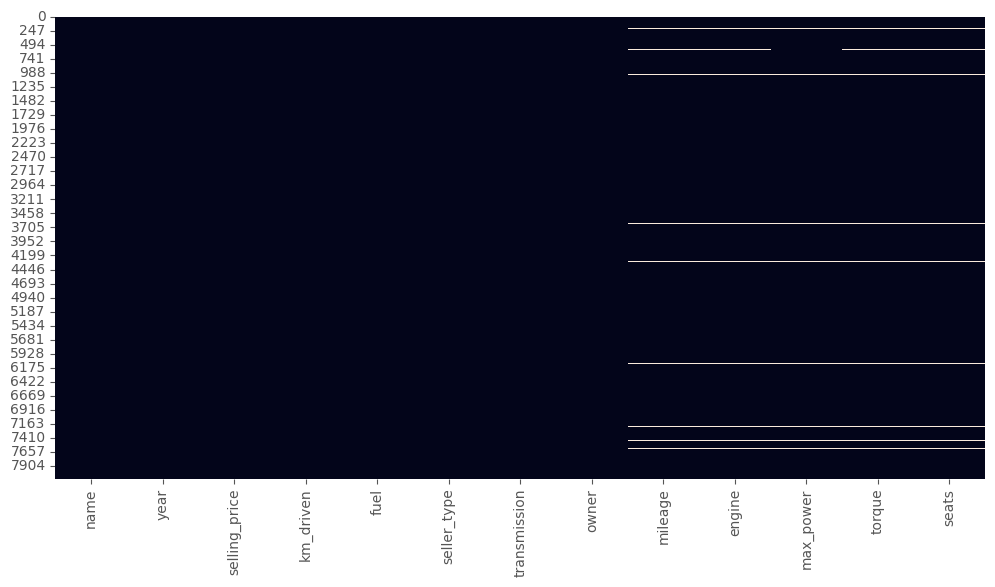

In [75]:
# Visualizing the missing values
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.show()

### What did you know about your dataset?

Answer Here



## ***2. Understanding Your Variables***

In [76]:
# Dataset Columns
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque',
       'seats'],
      dtype='object')

In [77]:
# Dataset Describe
df.describe()

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


### Variables Description

Answer Here



### Check Unique Values for each variable.

In [78]:
# Check Unique Values for each variable.

## 3. ***Data Wrangling***

### Data Wrangling Code

In [79]:
# Write your code to make your dataset analysis ready.

### What all manipulations have you done and insights you found?

Answer Here.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 (Selling Price Distribution)

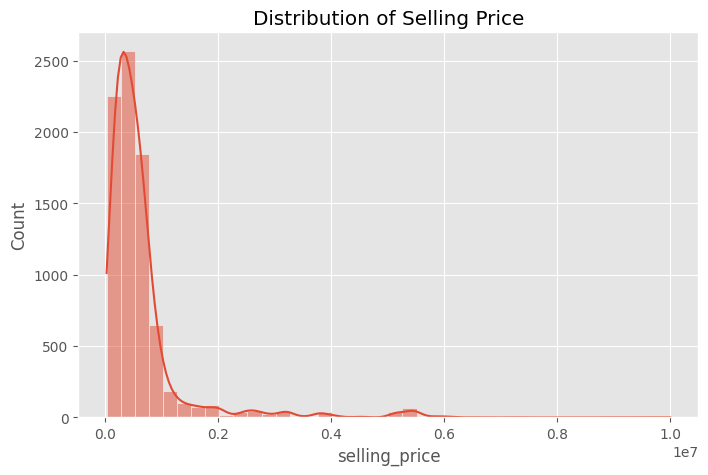

In [80]:
# Chart - 1 visualization code

plt.figure(figsize=(8,5))
sns.histplot(df['selling_price'], bins=40, kde=True)
plt.title("Distribution of Selling Price")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

Histogram is best for understanding the distribution of a continuous variable.

 2. What is/are the insight(s) found from the chart?

Answer Here

1) Most cars are sold in the lower price range.
2) Very expensive cars are comparatively few.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

Positive business impact

Dealers can focus inventory on the price range with the highest customer demand.

#### Chart - 2 (Vehicle Age Distribution)

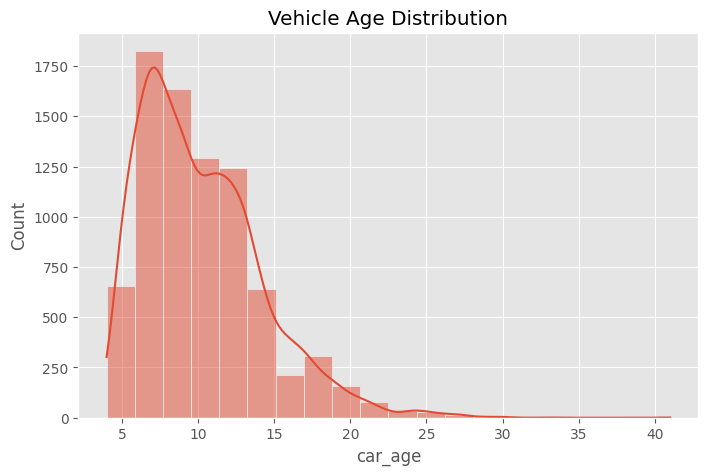

In [81]:
# Chart - 2 visualization code

df['car_age'] = 2024 - df['year']

plt.figure(figsize=(8,5))
sns.histplot(df['car_age'], bins=20, kde=True)
plt.title("Vehicle Age Distribution")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

A histogram is the most appropriate chart for visualizing the distribution of a continuous variable such as vehicle age. It shows how many cars belong to each age group, helping identify whether the dataset mainly contains newer, moderately aged, or older vehicles. This is important because vehicle age is one of the key factors influencing a car's resale price.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

1) The histogram shows the distribution of cars across different age groups.
2) If the chart has higher bars for lower vehicle ages, it indicates that newer cars dominate the dataset.
3) If the chart has higher bars for older vehicle ages, it indicates that the used-car market mainly consists of older vehicles.
4) Vehicle age is expected to have a strong relationship with selling price, where older cars generally have lower resale values due to depreciation.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

**Positive Business Impact:**

The analysis helps dealerships understand the age profile of vehicles available in the market.
If newer vehicles are more common, dealers can focus marketing efforts on certified pre-owned cars, which generally attract higher customer demand and better profit margins.
Vehicle age can also be used as an important feature for predicting selling prices more accurately in the regression model.

**Negative Growth (if applicable):**

If the dataset contains a high proportion of older vehicles, the average selling price may decrease because older cars depreciate significantly over time.
Older vehicles may require more maintenance, reducing customer interest and increasing inventory holding time, which can negatively impact business revenue.

#### Chart - 3 (Fuel Type Count)

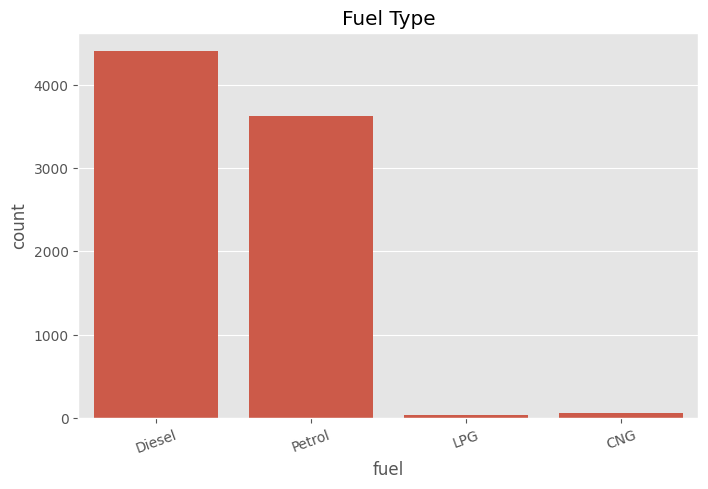

In [82]:
# Chart - 3 visualization code

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='fuel')
plt.title("Fuel Type")
plt.xticks(rotation=20)
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

A count plot (bar chart) is the most appropriate visualization for the Fuel column because it is a categorical variable. It clearly shows the number of cars available in each fuel category (Petrol, Diesel, CNG, LPG, Electric, etc.), making it easy to compare their frequencies and identify the most common fuel types in the dataset.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

1) The count plot reveals the distribution of vehicles across different fuel types.
2) In the CarDekho dataset, Petrol and Diesel cars generally constitute the majority of listings, while CNG, LPG, and Electric vehicles are comparatively fewer.
3) This indicates that the used-car market is still dominated by conventional fuel vehicles.
4) The chart also highlights the relative market share of alternative fuel vehicles.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

**Positive Business Impact:**

Understanding the most common fuel type helps dealerships maintain inventory that aligns with customer demand.
Marketing campaigns and pricing strategies can be tailored toward the most popular fuel categories, increasing sales opportunities.
Businesses can also identify growing alternative fuel segments (such as CNG or Electric) and prepare for future market demand.
Fuel type can be used as an important feature in the regression model, improving selling price prediction accuracy.

**Negative Growth (if applicable):**

If the inventory is heavily concentrated in one fuel type (for example, only Petrol or Diesel vehicles), the business becomes more vulnerable to changes in fuel prices, environmental regulations, or customer preferences.
A very low number of Electric or CNG vehicles may indicate that the dealership is not fully prepared for the growing demand for eco-friendly transportation, potentially resulting in missed future business opportunities.
An unbalanced inventory reduces product diversity, limiting customer choice and affecting long-term competitiveness.

#### Chart - 4 (Top 10 Car Brands)

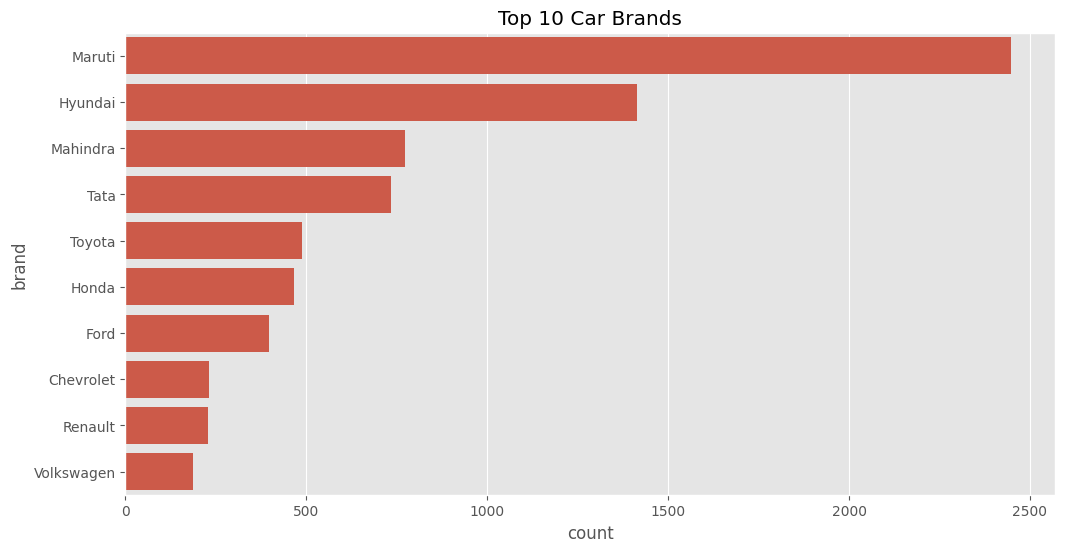

In [83]:
# Chart - 4 visualization code

df['brand'] = df['name'].str.split().str[0]

plt.figure(figsize=(12,6))
sns.countplot(data=df,
              y='brand',
              order=df['brand'].value_counts().head(10).index)

plt.title("Top 10 Car Brands")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

A count plot (horizontal bar chart) is the most suitable visualization for comparing the frequency of different car brands in the dataset. Since the dataset contains many brands, displaying the top 10 brands makes the chart easy to interpret while highlighting the brands with the highest number of listed vehicles. This chart helps identify market dominance and customer preferences.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

1) The chart identifies the top 10 most frequently listed car brands in the used-car market.
2) Brands such as Maruti, Hyundai, Honda, Mahindra, and Tata are expected to have the highest number of listings in the CarDekho dataset (confirm with your plotted chart).
3) A higher number of listings for a brand indicates its strong presence and popularity in the used-car market.
4) Brands with fewer listings may represent niche or premium segments with lower market availability.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

**Positive Business Impact:**

Dealerships can prioritize stocking and promoting the most popular brands, increasing the likelihood of faster sales.
Marketing campaigns can focus on brands with high customer demand, improving conversion rates and profitability.
Businesses can use this information to forecast inventory requirements and optimize procurement decisions.
Popular brands often have better resale value, making them attractive for both buyers and sellers.

**Negative Growth:**

Overdependence on a small number of brands may reduce product diversity and limit customer choices.
If customer preferences shift toward emerging brands or electric vehicle manufacturers, dealerships focusing only on traditional popular brands may experience reduced sales.
Premium or less common brands may receive less attention, resulting in slower inventory turnover and higher holding costs.

#### Chart - 5 (Average Selling Price by Fuel)

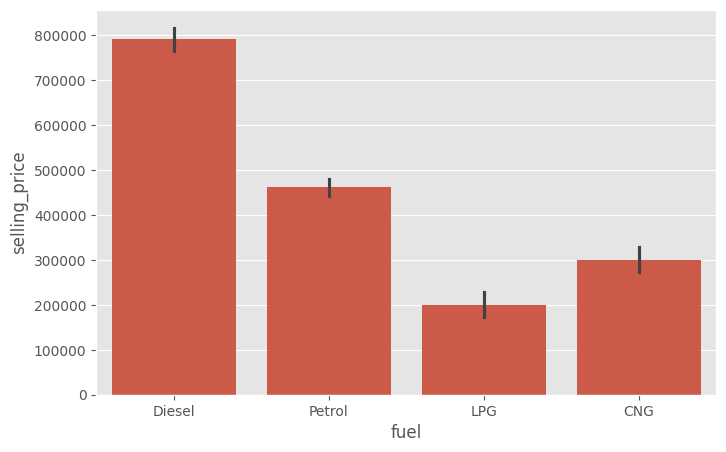

In [84]:
# Chart - 5 visualization code

plt.figure(figsize=(8,5))
sns.barplot(data=df,
            x='fuel',
            y='selling_price')

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

A bar plot is the most appropriate chart for comparing the average selling price across different fuel categories (Petrol, Diesel, CNG, LPG, Electric). Since fuel type is a categorical variable and selling price is a numerical variable, a bar chart clearly displays the average price for each category, making comparisons simple and effective.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

1. The chart compares the average selling price of cars based on their fuel type.
2. It helps identify which fuel category has the highest and lowest average resale value.
3. In the CarDekho dataset, Diesel and Electric vehicles often have higher average selling prices than Petrol, CNG, or LPG vehicles because they generally belong to premium or higher-end vehicle segments. (Confirm this with your plotted chart.
4. The chart indicates that fuel type is an important factor influencing the resale value of a vehicle.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

**Positive Business Impact:**

Dealerships can focus on stocking fuel categories that generate higher average selling prices, improving overall profitability.
Pricing strategies can be optimized by considering fuel type as a key factor in vehicle valuation.
Marketing campaigns can target customers based on fuel preferences and expected resale value.
The insight also improves the regression model because fuel type becomes an important predictive feature for estimating selling prices.

**Negative Growth**

If one fuel category has a significantly lower average selling price, dealerships may experience lower profit margins from selling those vehicles.
A heavy dependence on only one fuel category (such as Diesel) may become risky if government regulations, environmental policies, or customer preferences change.
Businesses that do not diversify their inventory may lose customers who prefer alternative fuel vehicles, especially as Electric vehicles become more popular.

#### Chart - 6 (Average Selling Price by Brand (Top 10))

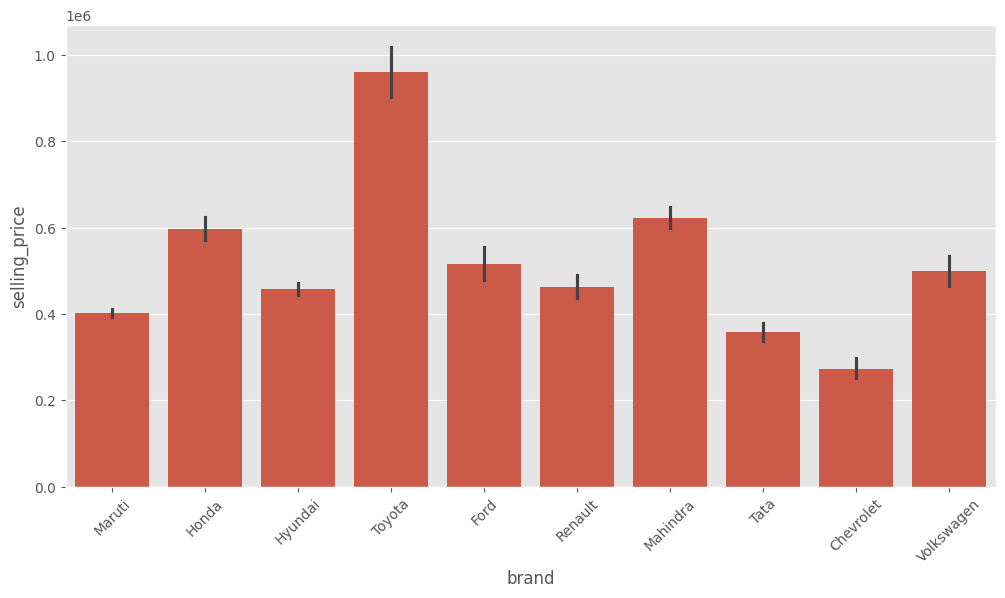

In [85]:
# Chart - 6 visualization code

top = df['brand'].value_counts().head(10).index

plt.figure(figsize=(12,6))
sns.barplot(data=df[df['brand'].isin(top)],
            x='brand',
            y='selling_price')

plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

A bar plot is the most suitable chart for comparing the average selling prices of the top 10 car brands. Since Brand is a categorical variable and Selling Price is a numerical variable, a bar chart clearly displays the average price of each brand, making it easy to compare their market value. Restricting the analysis to the top 10 brands keeps the visualization clear and easy to interpret.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

1. The chart shows the average selling price of the top 10 most common car brands in the dataset.
2. Some brands have a higher average selling price, indicating that they belong to the premium or luxury segment or have better resale value.
Brands with lower average selling prices are generally more affordable and cater to the mass market.
3. The variation in average prices across brands demonstrates that brand reputation and market positioning significantly influence resale value.
4. These insights confirm that brand is an important feature for predicting a car's selling price.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

***Positive Business Impact***

Dealerships can prioritize purchasing and stocking brands with higher average resale values, leading to increased profit margins.
Businesses can develop brand-specific pricing strategies, ensuring competitive and accurate pricing.
Marketing campaigns can focus on brands that offer high resale value, attracting more potential buyers.
These insights also improve the machine learning model, as brand is a strong predictor of selling price.

***Negative Growth***

Focusing only on premium brands may reduce affordability for budget-conscious customers, limiting the customer base.
Brands with consistently lower resale values may remain in inventory for longer periods, increasing storage and maintenance costs.
Ignoring emerging or less popular brands may result in missed business opportunities if consumer preferences shift over time.

#### Chart - 7 (Engine vs Selling Price)

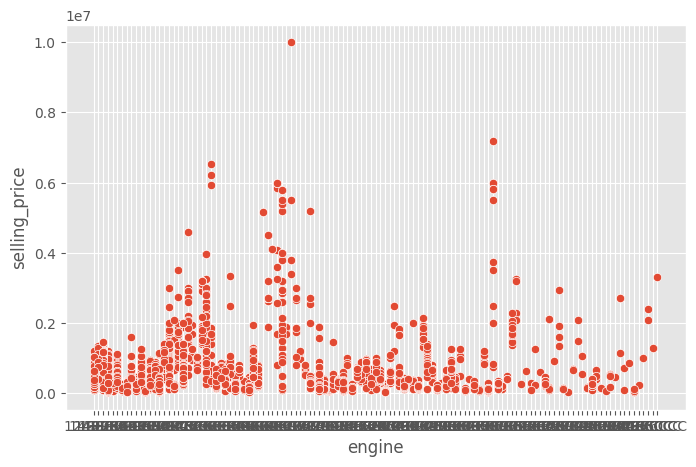

In [86]:
# Chart - 7 visualization code

plt.figure(figsize=(8,5))
sns.scatterplot(data=df,
                x='engine',
                y='selling_price')

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

A scatter plot is the most appropriate chart for analyzing the relationship between two continuous numerical variables: Engine Capacity (CC) and Selling Price. It helps visualize whether a correlation exists between engine size and resale value, identifies trends, clusters, and detects any outliers that may influence the regression model.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

1. The scatter plot shows how engine capacity affects the selling price of vehicles.
2. Generally, cars with larger engine capacities tend to have higher selling prices, indicating a positive relationship between engine size and resale value.
3. Although the overall trend is positive, some points may deviate from the pattern because selling price is also influenced by factors such as brand, vehicle age, mileage, transmission type, and overall condition.
4. The chart suggests that engine capacity is an important predictor of selling price and should be included in the regression model.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

***Positive Business Impact:***

Dealers can use engine capacity as a key factor while pricing used cars more accurately.
Customers looking for high-performance vehicles can be targeted with cars having larger engine capacities, improving customer satisfaction and sales.
The business can identify premium vehicle segments that generate higher profit margins.
Including engine capacity as a feature improves the accuracy of the regression model for predicting selling prices.

***Negative Growth:***

Vehicles with larger engine capacities generally have higher fuel consumption and maintenance costs, which may reduce demand among budget-conscious buyers.
If a dealership stocks only large-engine vehicles, it may lose customers seeking economical and fuel-efficient cars.
Future environmental regulations and increasing fuel prices may reduce demand for vehicles with large engines, affecting resale value and inventory turnover.

#### Chart - 8 (Mileage vs Selling Price)

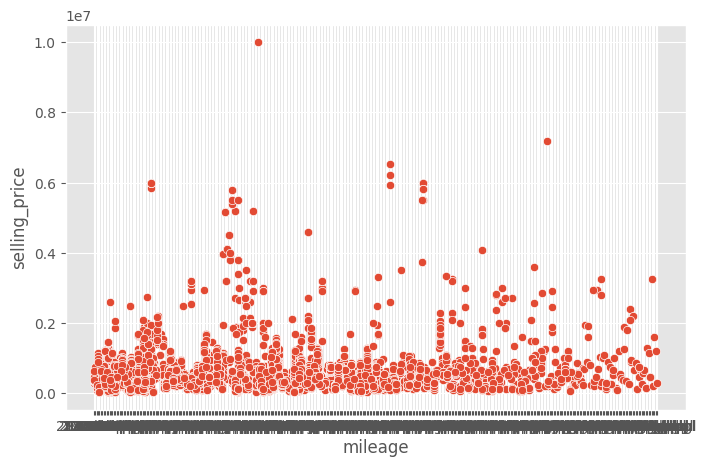

In [87]:
# Chart - 8 visualization code

plt.figure(figsize=(8,5))
sns.scatterplot(data=df,
                x='mileage',
                y='selling_price')

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

A scatter plot is the most suitable chart for visualizing the relationship between Mileage (km/l) and Selling Price, as both are continuous numerical variables. It helps identify whether there is a correlation between a car's fuel efficiency and its resale value. The chart also reveals trends, clusters, and outliers that may affect the regression model.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

1. The scatter plot illustrates how mileage influences the selling price of vehicles.
2. The relationship may not be perfectly linear because selling price is also affected by factors such as brand, engine capacity, vehicle age, transmission type, and kilometers driven.
3. Vehicles with good fuel efficiency (higher mileage) are generally more attractive to buyers, especially in the budget segment, which can contribute to better resale value.
4. The chart indicates that mileage is an important feature and should be considered while predicting the selling price.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

***Positive Business Impact:***

The analysis helps dealerships understand how fuel efficiency affects customer preferences and resale prices.
Cars with higher mileage can be marketed as economical and cost-effective, attracting budget-conscious buyers.
Mileage can be incorporated as an important feature in the regression model, improving the accuracy of selling price predictions.
Businesses can adjust pricing strategies based on the fuel efficiency of vehicles, leading to more competitive pricing.

***Negative Growth:***

Vehicles with lower mileage (poor fuel efficiency) may experience reduced demand due to higher fuel costs, making them harder to sell.
If a dealership stocks a large number of low-mileage vehicles, inventory turnover may slow down, increasing storage and maintenance costs.
Increasing fuel prices and growing environmental awareness may further reduce customer interest in less fuel-efficient vehicles.

#### Chart - 9 (Selling Price vs Kilometer Driven)

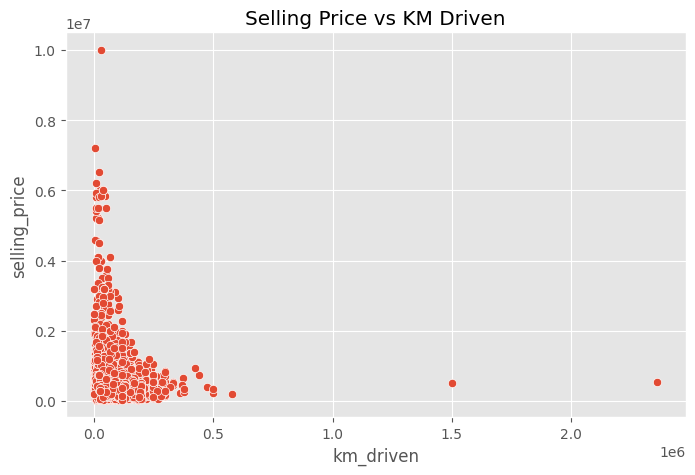

In [88]:
# Chart - 9 visualization code

plt.figure(figsize=(8,5))
sns.scatterplot(data=df,
                x='km_driven',
                y='selling_price')

plt.title("Selling Price vs KM Driven")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

A scatter plot is the most appropriate chart for analyzing the relationship between Kilometers Driven and Selling Price because both are continuous numerical variables. It helps identify whether there is a correlation between the distance a car has been driven and its resale value. The chart also reveals trends, clusters, and outliers that may influence the regression model.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

1. The scatter plot generally shows a negative relationship between kilometers driven and selling price.
2. Cars with lower kilometers driven usually have higher selling prices, as they are perceived to have less wear and tear.
3. As the number of kilometers driven increases, the selling price generally decreases due to depreciation and higher maintenance expectations.
4. A few outliers may exist where high-mileage cars still have high selling prices because of factors such as premium brands, newer manufacturing year, or better overall condition.
5. This indicates that kilometers driven is an important feature for predicting the selling price of a used car.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

***Positive Business Impact:***

Dealerships can use the number of kilometers driven to determine a fair and competitive selling price.
Vehicles with lower mileage can be highlighted in advertisements, increasing customer interest and improving sales.
The insight helps businesses estimate depreciation more accurately, leading to better pricing strategies and inventory valuation.
Including kilometers driven as a feature in the regression model improves prediction accuracy and supports data-driven decision-making.

***Negative Growth***

Cars with very high kilometers driven may experience lower customer demand because buyers often associate them with higher maintenance costs and shorter remaining lifespan.
If a dealership maintains a large inventory of high-mileage vehicles, these cars may remain unsold for longer periods, increasing storage and maintenance expenses.
Lower resale values for high-mileage vehicles can reduce overall profit margins and slow inventory turnover.

#### Chart - 10 (Selling Price by Fuel Type)

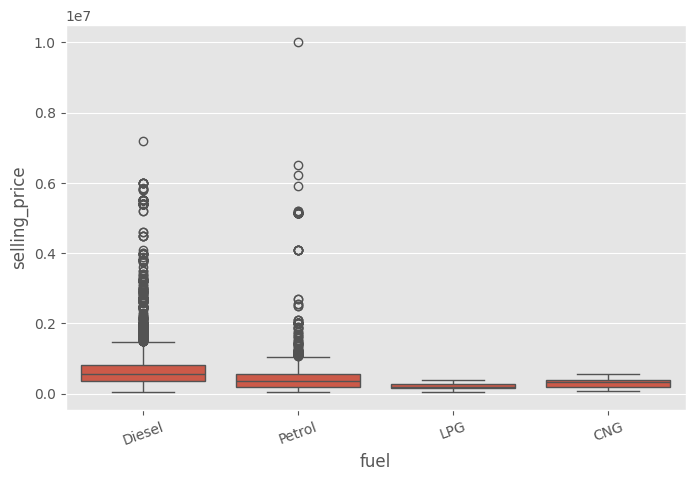

In [89]:
# Chart - 10 visualization code

plt.figure(figsize=(8,5))
sns.boxplot(data=df,
            x='fuel',
            y='selling_price')

plt.xticks(rotation=20)
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

A box plot is the most suitable chart for comparing the selling price distribution across different fuel types (Petrol, Diesel, CNG, LPG, Electric). Unlike a bar chart, a box plot displays the median, quartiles, spread, and outliers, making it easier to understand how selling prices vary within each fuel category.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

1.   The box plot compares the distribution of selling prices for each fuel type.

1.  It helps identify which fuel category has the highest median selling price and which has the lowest.
1.   The chart also shows the variation in selling prices within each fuel type, indicating whether prices are consistent or highly spread out.

2.   Outliers represent vehicles that are priced significantly higher or lower than the majority, often due to factors such as luxury brands, newer models, or special features.

2.   The differences among fuel categories suggest that fuel type is an important factor influencing the resale value of a car. item




##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

***Positive Business Impact:***
The analysis helps dealerships understand which fuel types generally command higher resale values, enabling better pricing strategies.
Businesses can adjust their inventory by stocking fuel categories that offer higher profitability and stronger market demand.
Customers can be offered vehicles based on their fuel preferences and budget, improving customer satisfaction.
Since fuel type significantly affects selling price, including it as a feature in the regression model improves prediction accuracy.

***Negative Growth***

Fuel categories with lower median selling prices may generate smaller profit margins and may require more competitive pricing to attract buyers.
If a dealership relies heavily on only one fuel category, changes in fuel prices, environmental regulations, or customer preferences may negatively affect sales.
Large variations in selling prices within a fuel category may make it difficult to establish consistent pricing, potentially reducing buyer confidence.


---



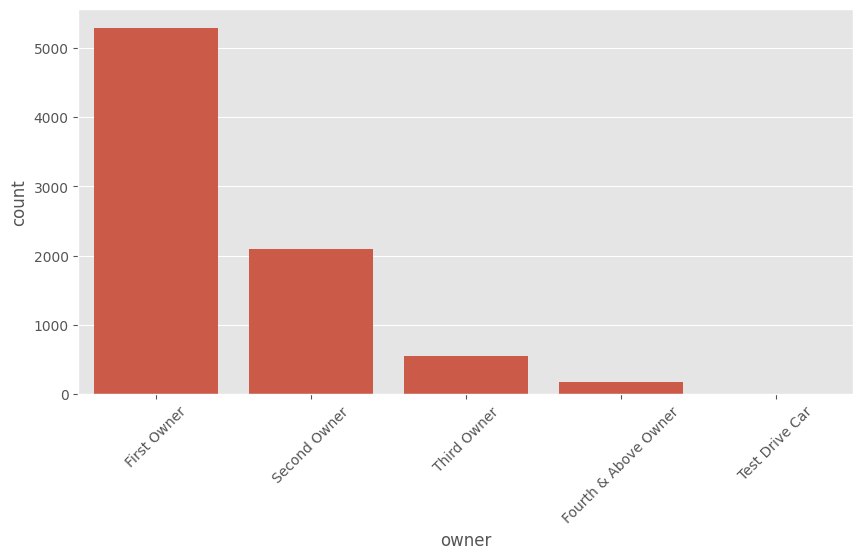

In [90]:
# Chart - 11 visualization code

plt.figure(figsize=(10,5))
sns.countplot(data=df, x="owner")
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

A count plot is the most appropriate visualization for the owner column because it is a categorical variable. It clearly displays the frequency of cars belonging to different ownership categories (First Owner, Second Owner, Third Owner, etc.), making it easy to compare the number of vehicles in each category.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

1. First Owner vehicles make up the largest proportion of the dataset.
Second Owner vehicles are the next most common category.
2. Cars with Third Owner, Fourth & Above Owner, or Test Drive Car status appear much less frequently.
3. This indicates that most used cars listed for sale have had relatively few previous owners, suggesting that buyers and sellers tend to prefer vehicles with fewer ownership transfers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

***Positive Business Impact:***

Dealers and online marketplaces can prioritize First Owner vehicles because they generally attract more customer interest and often command higher resale prices.
The insight can also improve the accuracy of car price prediction models, as the number of previous owners is an important factor influencing resale value.
Marketing campaigns highlighting "First Owner" vehicles may increase customer trust and improve sales.

***Negative Growth Insight:***

Vehicles with multiple previous owners may experience lower customer demand and reduced resale value.
If a dealership's inventory contains a high proportion of Third Owner or Fourth Owner cars, it may result in slower sales, lower profit margins, and increased inventory holding costs.
Therefore, maintaining a balanced inventory with a higher proportion of low-owner vehicles can improve overall business performance.

#### Chart - 12 Transmission Type

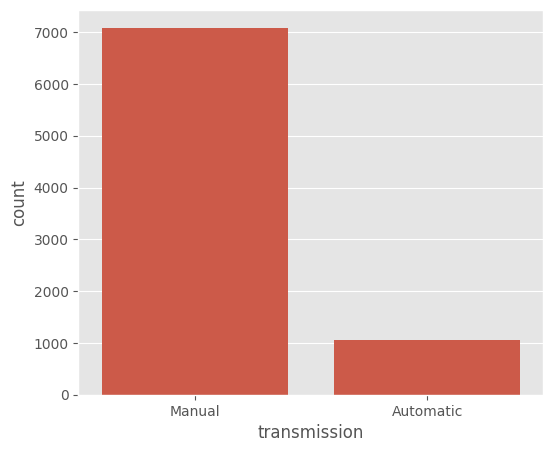

In [91]:
# Chart - 12 visualization code

plt.figure(figsize=(6,5))
sns.countplot(data=df, x="transmission")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

A count plot is the most appropriate visualization for the owner column because it is a categorical variable. It clearly displays the frequency of cars belonging to different ownership categories (First Owner, Second Owner, Third Owner, etc.), making it easy to compare the number of vehicles in each category.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

1. First Owner vehicles make up the largest proportion of the dataset.
Second Owner vehicles are the next most common category.
2. Cars with Third Owner, Fourth & Above Owner, or Test Drive Car status appear much less frequently.
3. This indicates that most used cars listed for sale have had relatively few previous owners, suggesting that buyers and sellers tend to prefer vehicles with fewer ownership transfers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

***Positive Business Impact:***

Dealers and online marketplaces can prioritize First Owner vehicles because they generally attract more customer interest and often command higher resale prices.
The insight can also improve the accuracy of car price prediction models, as the number of previous owners is an important factor influencing resale value.
Marketing campaigns highlighting "First Owner" vehicles may increase customer trust and improve sales.

***Negative Growth Insight:***

Vehicles with multiple previous owners may experience lower customer demand and reduced resale value.
If a dealership's inventory contains a high proportion of Third Owner or Fourth Owner cars, it may result in slower sales, lower profit margins, and increased inventory holding costs.
Therefore, maintaining a balanced inventory with a higher proportion of low-owner vehicles can improve overall business performance.

#### Chart - 13 (Max Power vs Selling Price)

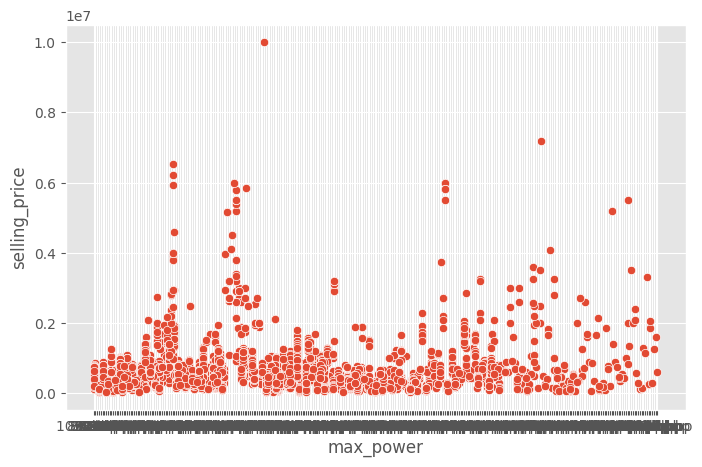

In [92]:
# Chart - 13 visualization code

plt.figure(figsize=(8,5))
sns.scatterplot(data=df,
                x='max_power',
                y='selling_price')

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

A scatter plot is the most appropriate chart for analyzing the relationship between Maximum Power (BHP) and Selling Price because both variables are continuous numerical variables. This chart helps identify whether cars with higher engine power generally have higher resale values. It also reveals trends, clusters, and outliers that are useful for understanding the relationship and improving the regression model.

##### 2. What is/are the insight(s) found from the chart?


Answer Here

1. The scatter plot generally shows a positive relationship between maximum power and selling price.
2. Cars with higher maximum power tend to have higher selling prices, as they are usually premium or performance-oriented vehicles.
3. Some vehicles with similar power ratings may have different selling prices because other factors such as brand, manufacturing year, mileage, transmission type, and vehicle condition also influence the resale value.
4. A few outliers may be observed where vehicles with relatively low power have high prices due to premium branding or luxury features.
5. These observations indicate that maximum power is an important predictor of a car's selling price.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

***Positive Business Impact:***

Dealerships can use maximum power as an important factor while estimating the resale value of used cars.
High-performance vehicles can be targeted toward customers looking for premium features, helping increase profit margins.
Businesses can segment their inventory into economy, mid-range, and performance vehicles, improving marketing strategies and customer targeting.
Including maximum power as a feature in the regression model improves the accuracy of selling price predictions.

***Negative Growth:***

High-power vehicles generally have higher fuel consumption, insurance premiums, and maintenance costs, which may reduce demand among budget-conscious buyers.
If a dealership stocks only high-performance vehicles, the customer base becomes limited, resulting in slower inventory turnover.
Changes in fuel prices or stricter environmental regulations may reduce demand for high-power vehicles, negatively affecting resale values and profitability.

#### Chart - 14 - Correlation Heatmap

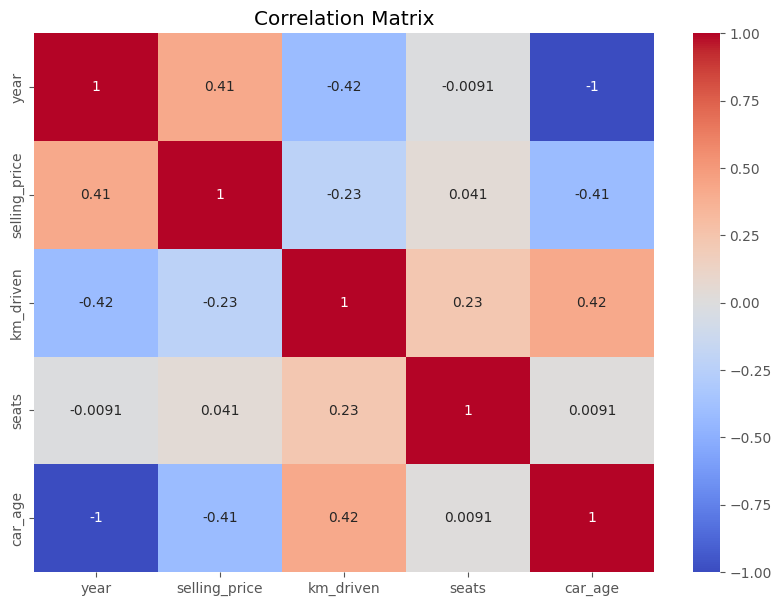

In [93]:
# Correlation Heatmap visualization code

plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

A correlation heatmap is the most suitable chart for analyzing the relationship between multiple numerical variables simultaneously. It uses color intensity to represent the strength and direction of correlation, making it easy to identify which features have the strongest influence on the selling price and whether any independent variables are highly correlated with each other. This is especially useful before building Linear, Ridge, and Lasso Regression models.

##### 2. What is/are the insight(s) found from the chart?


Answer Here

1. The heatmap shows the correlation coefficient between all numerical variables in the dataset.
2. Variables with correlation values close to +1 have a strong positive relationship, while values close to -1 indicate a strong negative relationship.
3. Features such as max_power, engine, and year often show a positive correlation with selling price, whereas car_age and km_driven generally show a negative correlation. (Confirm these relationships from your actual heatmap.)
4. The heatmap also helps identify multicollinearity, where two or more independent variables are highly correlated with each other. This information is important because highly correlated features can affect regression model performance.

#### Chart - 15 - Pair Plot

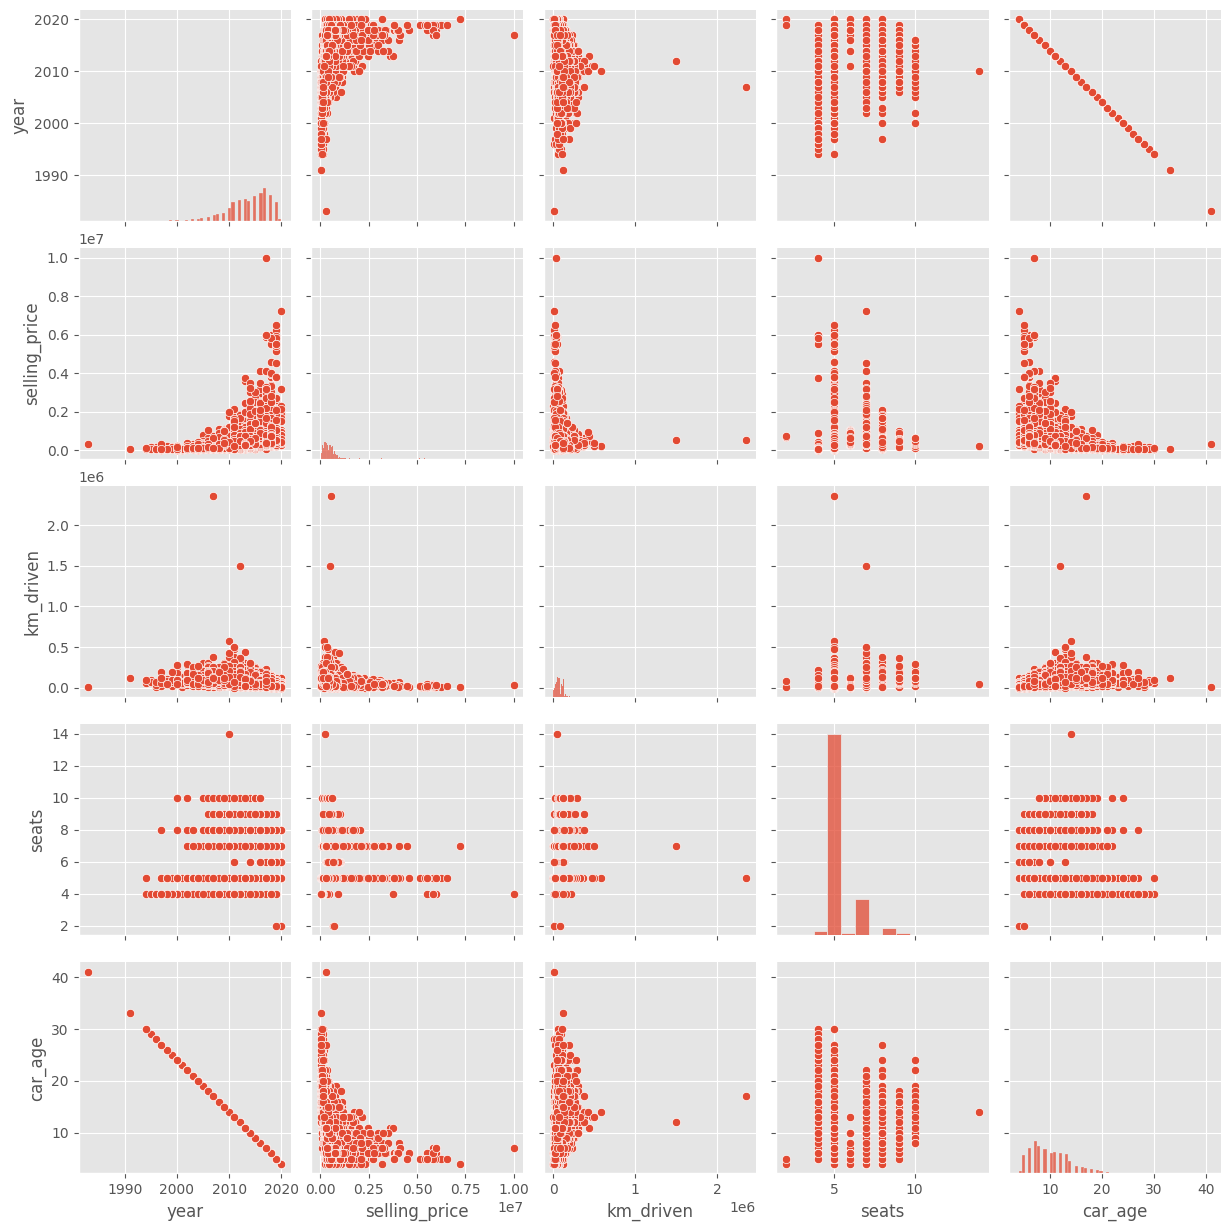

In [94]:
# Pair Plot visualization code
sns.pairplot(df)

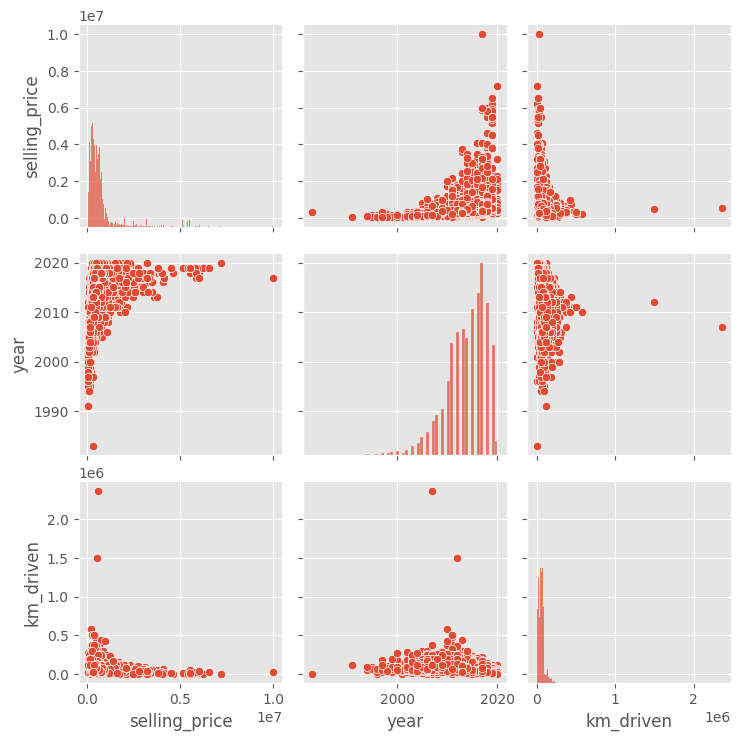

In [95]:
sns.pairplot(df[['selling_price',
                 'year',
                 'km_driven',
                 'mileage',
                 'engine',
                 'max_power']])

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

A pairplot is an excellent exploratory data analysis (EDA) chart because it simultaneously visualizes the relationships between multiple numerical variables. It combines scatter plots for pairwise relationships and histograms (or density plots) for individual variable distributions. This makes it easy to identify trends, correlations, clusters, and outliers in a single visualization before building regression models.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

1. The pairplot helps identify linear and non-linear relationships among important numerical variables such as selling_price, year, km_driven, mileage, engine, and max_power.
2. It shows that variables such as engine and max_power generally have a positive relationship with selling_price, while km_driven tends to show a negative relationship with selling price. (Verify these trends using your plotted pairplot.)
3. The diagonal plots display the distribution of each numerical variable, helping identify skewness and potential outliers.
The scatter plots also reveal whether variables are suitable for regression analysis by indicating the strength of their relationships.

## ***6. Feature Engineering & Data Pre-processing***



### 1. Handling Missing Values

In [96]:
# Handling Missing Values & Missing Value Imputation

df.isnull().sum()



,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage,221
engine,221


Percentage of Missing Values

In [97]:
missing_percentage = (df.isnull().sum()/len(df))*100
missing_percentage.sort_values(ascending=False)

,0
torque,2.731299
mileage,2.718996
seats,2.718996
engine,2.718996
max_power,2.645177
year,0.000000
name,0.000000
transmission,0.000000
seller_type,0.000000
fuel,0.000000


Fill Missing Values

In [126]:
# Numerical Columns

num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)


# Categorical Columns

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

Verify Missing Values

In [99]:
df.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage,0
engine,0


Feature Engineering : Car Age

In [127]:
current_year = 2024
df["car_age"] = current_year - df["year"]
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,car_age,brand
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0,10,Maruti
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0,10,Skoda
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0,18,Honda
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0,14,Hyundai
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0,17,Maruti


What all missing value imputation techniques have you used and why did you use those techniques?



Answer Here.

### 2. Handling Outliers

In [100]:
# Handling Outliers & Outlier treatments

Q1 = df['selling_price'].quantile(0.25)
Q3 = df['selling_price'].quantile(0.75)

IQR = Q3-Q1

lower = Q1-1.5*IQR
upper = Q3+1.5*IQR

df = df[(df['selling_price']>=lower)&(df['selling_price']<=upper)]



##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.

### 3. Categorical Encoding

In [101]:
# Encode your categorical columns

#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [102]:
# Expand Contraction

#### 2. Lower Casing

In [103]:
# Lower Casing

#### 3. Removing Punctuations

In [104]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [105]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [106]:
# Remove Stopwords

In [107]:
# Remove White spaces

#### 6. Rephrase Text

In [108]:
# Rephrase Text

#### 7. Tokenization

In [109]:
# Tokenization

#### 8. Text Normalization

In [110]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [111]:
# POS Taging

#### 10. Text Vectorization

In [112]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [113]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [114]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

Answer Here.

##### Which all features you found important and why?

Answer Here.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [115]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [116]:
# Split your data to train and test. Choose Splitting ratio wisely.

##### What data splitting ratio have you used and why?

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [117]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [118]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [119]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [120]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [121]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

In [122]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [123]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [124]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***